# Where are the Met Office stations in the UK?
This notebook looks into where the weather stations are in the UK and create a visual for them.

In [35]:
# packages
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

## Geo file of the UK
First, we need to initialise the file that holds the UK. The file is from [the UK GOV website](https://geoportal.statistics.gov.uk/datasets/92150c7aa60540c5814abe3b26bce6d0_0/explore?location=55.340000%2C-3.316939%2C5) It shows the Local authorities around the UK.

In [36]:
# geopackage file
gpkg_file = (
    Path.cwd().parent / "input" / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_4018006726868062741.gpkg"
)
gdf_authorities = gpd.read_file(gpkg_file)
gdf_authorities.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [37]:
# clean the geodataframe
gdf_authorities = (
    gdf_authorities
    .rename(columns={"LAD25NM": "local_authority_name", "LAD25CD": "local_authority_code"})
    .loc[:, ["local_authority_name", "local_authority_code", "geometry"]]
)
gdf_authorities.head(2)

,local_authority_name,local_authority_code,geometry
0,Hartlepool,E06000001,"MULTIPOLYGON (((447213.9 537036.104, 447206.00..."
1,Middlesbrough,E06000002,"MULTIPOLYGON (((448609.9 521982.6, 448586.35 5..."


We see that the GeoPackage file has a coordinate reference system of 27700.

## Locate weather stations
Now we have to find where the location of the Met Office weather stations are. These are on the Met Office website that has a table full of their attributes. It is the same webpage that I used `scrape.py` to get information from. This means I already have this information.


We need to change the longitude and latitude points into a geometry and ensure the coordinate reference system is the same as the geo data frame above. This is so we can join them and ind a location.

In [38]:
# location of weather stations
location_filename = "location_webpages"
input_location_filepath = (
    Path.cwd().parent / "input" / f"{location_filename}.csv"
)
df_stations = pd.read_csv(input_location_filepath)
df_stations[["longitude", "latitude"]] = df_stations["Location"].str.split(
    pat=",", n=2, expand=True
)
df_stations = df_stations[["Name", "longitude", "latitude", "Opened"]]

In [39]:
# create geopandas df with location points
gdf_stations = gpd.GeoDataFrame(
    df_stations,
    geometry=gpd.points_from_xy(df_stations.longitude, df_stations.latitude),
    crs="EPSG:4326",
).to_crs("EPSG:27700")

In [40]:
gdf_stations.head(2)

,Name,longitude,latitude,Opened,geometry
0,Aberporth,-4.57,52.139,1941,POINT (224221.293 252082.777)
1,Armagh,-6.649,54.352,1853,POINT (98032.063 505131.275)


## Visualise the data
We will now create visuals to show the map of the UK and also the map of the UK with points where the weather stations are.

Text(0.5, 0.98, 'Local Authorities in the UK')

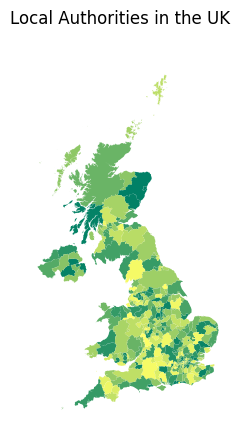

In [41]:
fig, ax = plt.subplots()
gdf_authorities.plot(ax=ax, column="local_authority_name", cmap="summer")
ax.set_axis_off()
fig.suptitle("Local Authorities in the UK")

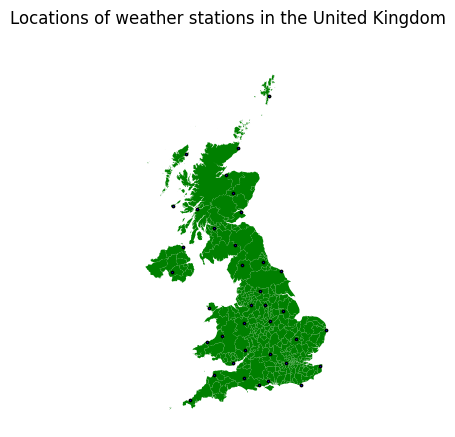

In [42]:
# combine in a visualisation
fig, ax = plt.subplots()
fig.suptitle("Locations of weather stations in the United Kingdom")
gdf_authorities.plot(ax=ax, color="green")
gdf_stations.plot(ax=ax, color="blue", edgecolor="black", markersize=3)
ax.set_axis_off()

## Which local authorities hold a weather station?
Now we can find where the weather station are.

In [43]:
# spatial join
gdf_point_in_country = gpd.sjoin(
    gdf_stations[["Name", "Opened", "geometry"]],
    gdf_authorities[["local_authority_name", "geometry"]],
    how="left"
)

In [44]:
gdf_point_in_country.head(2)

,Name,Opened,geometry,index_right,local_authority_name
0,Aberporth,1941,POINT (224221.293 252082.777),345.0,Ceredigion
1,Armagh,1853,POINT (98032.063 505131.275),297.0,"Armagh City, Banbridge and Craigavon"


In [47]:
df_station_authorities = gdf_point_in_country.drop(columns=["geometry", "index_right"])
df_station_authorities

,Name,Opened,local_authority_name
0,Aberporth,1941,Ceredigion
1,Armagh,1853,"Armagh City, Banbridge and Craigavon"
2,Ballypatrick Forest,1961,Causeway Coast and Glens
3,Bradford,1908,Bradford
4,Braemar No 2,1959,Aberdeenshire
5,Camborne,1978,Cornwall
6,Cambridge Niab,1959,South Cambridgeshire
7,Cardiff Bute Park,1977,Cardiff
8,Chivenor,1951,North Devon
9,Cwmystwyth,1959,Ceredigion
